### **Objective**

In this notebook, we build and train a Convolutional Neural Network (CNN) to classify dermoscopic skin lesion images into seven disease categories.

The notebook includes:

- Loading processed data
- Creating image generators
- Designing the CNN architecture
- Model training
- Performance evaluation
- Saving the trained model

# **Import Libraries**

In [1]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Dropout,
    Flatten,
    Dense
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

# **Mount Google Drive**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Define Project Directories**

In [3]:
PROJECT_DIR = "/content/drive/MyDrive/AI-TeleTriage-System"

SAVE_DIR = os.path.join(PROJECT_DIR, "saved_objects")
DATASET_DIR = os.path.join(PROJECT_DIR, "dataset")
MODEL_DIR = os.path.join(PROJECT_DIR, "models")

# **Load Saved Objects**

In [4]:
with open(os.path.join(SAVE_DIR, "train_df.pkl"), "rb") as f:
    train_df = pickle.load(f)

with open(os.path.join(SAVE_DIR, "val_df.pkl"), "rb") as f:
    val_df = pickle.load(f)

with open(os.path.join(SAVE_DIR, "test_df.pkl"), "rb") as f:
    test_df = pickle.load(f)

with open(os.path.join(SAVE_DIR, "class_weights.pkl"), "rb") as f:
    class_weights = pickle.load(f)

print("All saved objects loaded successfully!")

All saved objects loaded successfully!


# **Verify the Data**

In [5]:
print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

train_df.head()

(7010, 10)
(1502, 10)
(1503, 10)


,lesion_id,image_id,dx,dx_type,age,sex,localization,path,disease,label
4357,HAM_0000946,ISIC_0031775,nv,follow_up,60.0,male,trunk,/content/drive/MyDrive/AI-TeleTriage-System/da...,Melanocytic Nevi,5
1751,HAM_0006097,ISIC_0027306,mel,histo,60.0,male,chest,/content/drive/MyDrive/AI-TeleTriage-System/da...,Melanoma,4
9527,HAM_0004348,ISIC_0033895,nv,consensus,40.0,female,unknown,/content/drive/MyDrive/AI-TeleTriage-System/da...,Melanocytic Nevi,5
8311,HAM_0006608,ISIC_0025491,nv,histo,60.0,male,back,/content/drive/MyDrive/AI-TeleTriage-System/da...,Melanocytic Nevi,5
1214,HAM_0005678,ISIC_0031023,mel,histo,60.0,male,chest,/content/drive/MyDrive/AI-TeleTriage-System/da...,Melanoma,4


# **Recreate the Generators**

In [6]:
#Even though we made them in Notebook 2, we recreate them here because generators are lightweight and depend on the current runtime
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [7]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    shear_range=0.10,
    horizontal_flip=True,
    fill_mode="nearest"
)

valid_test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [8]:
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="path",
    y_col="dx",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=42
)

val_generator = valid_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="path",
    y_col="dx",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_generator = valid_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="path",
    y_col="dx",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 7010 validated image filenames belonging to 7 classes.
Found 1502 validated image filenames belonging to 7 classes.
Found 1503 validated image filenames belonging to 7 classes.


# **Verify**

In [9]:
print(train_generator.class_indices)

images, labels = next(train_generator)

print(images.shape)
print(labels.shape)

{'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}
(32, 224, 224, 3)
(32, 7)


# **Build the CNN Architecture**

In [10]:
# Input Image (224×224×3)
#         │
#         ▼
# Conv2D (32)
#         │
# BatchNormalization
#         │
# ReLU
#         │
# MaxPooling
#         │
# Dropout
#         │
# ────────────────────────────
# Conv2D (64)
#         │
# BatchNormalization
#         │
# ReLU
#         │
# MaxPooling
#         │
# Dropout
#         │
# ────────────────────────────
# Conv2D (128)
#         │
# BatchNormalization
#         │
# ReLU
#         │
# MaxPooling
#         │
# Dropout
#         │
# ────────────────────────────
# Conv2D (256)
#         │
# BatchNormalization
#         │
# ReLU
#         │
# MaxPooling
#         │
# Dropout
#         │
# ────────────────────────────
# Flatten
#         │
# Dense(256)
#         │
# Dropout
#         │
# Dense(128)
#         │
# Dropout
#         │
# Dense(7)
#         │
# Softmax

**Why this architecture?**

***input_shape = (224,224,3)***<br>
Because every image generator produces: 224 × 224 × RGB

***Conv2D(32)***

Why 32 filters?

The first layer learns simple features:

* edges
* corners
* colors
* texture

We don't need hundreds of filters yet.

***Batch Normalization***

It:

* stabilizes learning
* speeds up convergence
* reduces internal covariate shift
* often improves accuracy

Nowadays almost every modern CNN uses Batch Normalization.

***MaxPooling***

It reduces computation while keeping the most important information.

***Dropout(0.25)***

This prevents overfitting.

Every batch randomly turns off 25% of neurons.

This forces the network to learn more robust features.

***Why increase filters?***

32<br>
↓<br>
64<br>
↓<br>
128<br>
↓<br>
256<br>


As the image gets smaller,

the features become more complex.

So we increase the number of filters.

This is standard CNN design.

***Flatten***

Converts 7×7×256 into 12544 so Dense layers can use it.

***Dense(256)***

This is where the CNN combines all learned features.

Think of it as the "decision making" layer.

***Dense(128)***

Adds another level of abstraction before classification.

***Dense(7)***

Because we have 7 diseases. One neuron per disease.

***Softmax***

Converts outputs into probabilities. Converts outputs into probabilities.



**Why did you choose this architecture?**

The architecture progressively increases the number of convolutional filters from 32 to 256 to capture increasingly complex image features. Batch Normalization improves training stability, MaxPooling reduces spatial dimensions and computation, and Dropout helps prevent overfitting. Finally, fully connected layers learn high-level feature combinations before the Softmax layer predicts one of the seven skin disease classes.

# **Build the Model**

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Dropout,
    Flatten,
    Dense
)

model = Sequential([

    # Block 1
    Conv2D(32, (3,3), activation='relu', padding='same',
           input_shape=(224,224,3)),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    # Block 2
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    # Block 3
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.30),

    # Block 4
    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.30),

    Flatten(),

    Dense(256, activation='relu'),
    Dropout(0.50),

    Dense(128, activation='relu'),
    Dropout(0.30),

    Dense(7, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,269,447 (50.62 MB)

 Trainable params: 13,268,487 (50.62 MB)

 Non-trainable params: 960 (3.75 KB)

Our CNN is good, but it can be improved.

The Dense layer alone has:

12.8 MILLION parameters

Almost 97% of the parameters belong to just one Dense layer.

Your dataset has 10,015 images

Training a model with 13.2 Million parameters is very likely to:

* overfit
* train slower
* use more RAM
* not necessarily improve accuracy

# **Improved model**

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Dropout,
    Flatten,
    Dense
)

model = Sequential([

    # Block 1
    Conv2D(32, (3,3), activation='relu', padding='same',
           input_shape=(224,224,3)),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    # Block 2
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    # Block 3
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.30),

    # Block 4
    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.30),

    GlobalAveragePooling2D(),


    Dense(256, activation='relu'),
    Dropout(0.50),

    Dense(128, activation='relu'),
    Dropout(0.30),

    Dense(7, activation='softmax')
])

In [14]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 489,927 (1.87 MB)

 Trainable params: 488,967 (1.87 MB)

 Non-trainable params: 960 (3.75 KB)

Replacing Flatten() with GlobalAveragePooling2D()

This gives:

* much fewer parameters
* faster training
* better generalization
* architecture closer to modern research

# **Compile the Model**

In [22]:
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)

model.compile(
    optimizer=optimizer,
    loss="categorical_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

# **Create Callbacks**

In [23]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

checkpoint = ModelCheckpoint(
    filepath=os.path.join(MODEL_DIR, "custom_cnn_best.keras"),
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

callbacks = [checkpoint, early_stop, reduce_lr]

Why these callbacks?<br>
✅ ModelCheckpoint<br>
Automatically saves the best model.<br>
✅ EarlyStopping<br>
Stops training if validation performance stops improving.<br>
This helps prevent overfitting and saves training time.<br>
✅ ReduceLROnPlateau<br>
If validation loss stops improving:<br>
TensorFlow automatically lowers the learning rate.<br>
This often helps the model converge to a better solution.

# **Train the Model**

In [24]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 741ms/step - accuracy: 0.4622 - loss: 1.5651 - precision: 0.7546 - recall: 0.3176
Epoch 1: val_accuracy improved from None to 0.51198, saving model to /content/drive/MyDrive/AI-TeleTriage-System/models/custom_cnn_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/AI-TeleTriage-System/models/custom_cnn_best.keras
220/220 ━━━━━━━━━━━━━━━━━━━━ 195s 831ms/step - accuracy: 0.4703 - loss: 1.5059 - precision: 0.7711 - recall: 0.3238 - val_accuracy: 0.5120 - val_loss: 1.2559 - val_precision: 0.8804 - val_recall: 0.3382 - learning_rate: 1.0000e-04
Epoch 2/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 706ms/step - accuracy: 0.4616 - loss: 1.5022 - precision: 0.7761 - recall: 0.3255
Epoch 2: val_accuracy did not improve from 0.51198
220/220 ━━━━━━━━━━━━━━━━━━━━ 171s 777ms/step - accuracy: 0.4586 - loss: 1.5175 - precision: 0.7760 - recall: 0.3167 - val_accuracy: 0.4887 - val_loss: 1.3099 - val_precision: 0.8706 - val_recall: 0.3136 - learning_rate

# **Improve this baseline a little**

Improvements made<br>
✅ Added a 5th Convolution block (512 filters)<br>
✅ Used GlobalAveragePooling2D (better than Flatten)<br>
✅ Increased Dense layer size (512 → 256)<br>
✅ Reduced Dropout slightly<br>
✅ Kept BatchNormalization<br>
✅ Kept the same input size (224×224×3)

In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, BatchNormalization,
    Dropout, GlobalAveragePooling2D, Dense
)

model = Sequential([

    Input(shape=(224, 224, 3)),

    # Block 1
    Conv2D(32, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    # Block 2
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    # Block 3
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.30),

    # Block 4
    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.35),

    # NEW Block 5
    Conv2D(512, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.40),

    # Classifier
    GlobalAveragePooling2D(),

    Dense(512, activation='relu'),
    Dropout(0.50),

    Dense(256, activation='relu'),
    Dropout(0.40),

    Dense(7, activation='softmax')
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 14, 14, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 14, 14, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │       262,65

 Total params: 1,968,327 (7.51 MB)

 Trainable params: 1,966,343 (7.50 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [26]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

In [27]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 768ms/step - accuracy: 0.2873 - loss: 2.2163 - precision: 0.4440 - recall: 0.1678
Epoch 1: val_accuracy did not improve from 0.51198
220/220 ━━━━━━━━━━━━━━━━━━━━ 205s 859ms/step - accuracy: 0.3248 - loss: 2.0431 - precision: 0.5235 - recall: 0.1830 - val_accuracy: 0.0113 - val_loss: 2.9054 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 2/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 721ms/step - accuracy: 0.4071 - loss: 1.7689 - precision: 0.6982 - recall: 0.2463
Epoch 2: val_accuracy did not improve from 0.51198
220/220 ━━━━━━━━━━━━━━━━━━━━ 177s 796ms/step - accuracy: 0.4029 - loss: 1.7894 - precision: 0.7178 - recall: 0.2398 - val_accuracy: 0.1079 - val_loss: 2.6574 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 3/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 718ms/step - accuracy: 0.4007 - loss: 1.6921 - precision: 0.6901 - recall: 0.2395
Epoch 3: val_accuracy did not improve from 0.

# **Save the Final Model**

In [ ]:
model.save(os.path.join(MODEL_DIR, "custom_cnn_final.keras"))

print("Final model saved successfully!")

# **Plot Training Curves**

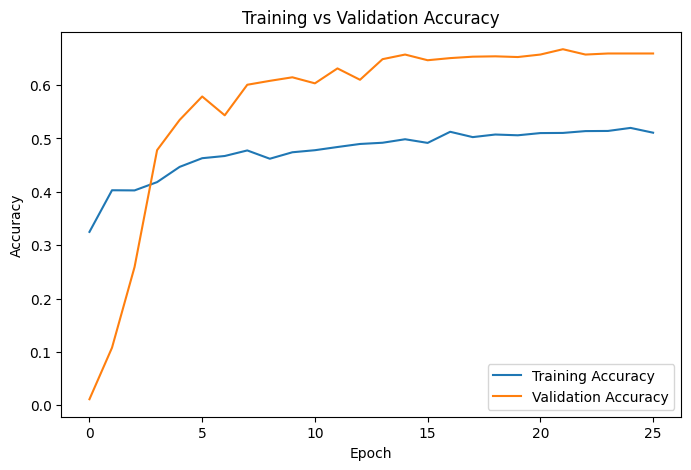

In [28]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()

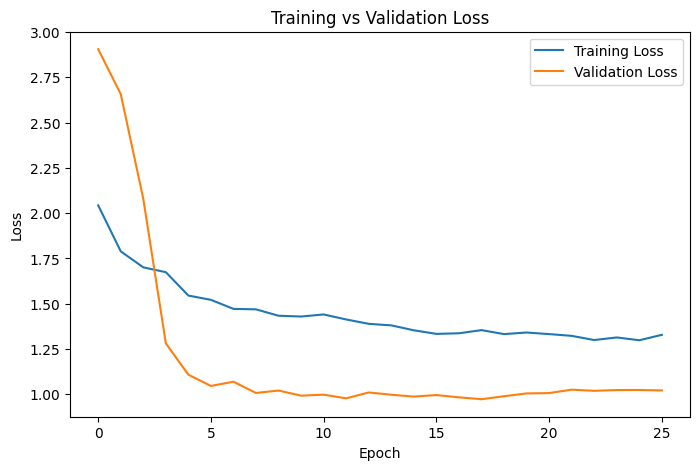

In [29]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

# **Evaluate on Test Data**

In [ ]:
test_loss, test_accuracy = model.evaluate(test_generator)

print(f"Test Loss : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")

 4/47 ━━━━━━━━━━━━━━━━━━━━ 9:19 13s/step - accuracy: 0.6829 - loss: 0.8415 - precision: 0.8128 - recall: 0.6348

# **Predictions**

In [ ]:
predictions = model.predict(test_generator)

predicted_classes = np.argmax(predictions, axis=1)

true_classes = test_generator.classes

# **Classification Report**

In [ ]:
from sklearn.metrics import classification_report
print(
    classification_report(
        true_classes,
        predicted_classes,
        target_names=list(test_generator.class_indices.keys())
    )
)

# **Confusion Matrix**

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(true_classes, predicted_classes)

print(cm)

In [ ]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=list(test_generator.class_indices.keys()),
    yticklabels=list(test_generator.class_indices.keys())
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

It still stays around 50–55%, then we stop trying to improve it because the limitation is the dataset size and training from scratch—not your implementation.

Then we'll move to DenseNet121, which should perform significantly better

In [ ]:
with open(os.path.join(SAVE_DIR, "custom_cnn_history.pkl"), "wb") as f:
    pickle.dump(history.history, f)

print("Training history saved!")

"The custom CNN achieved approximately X% validation accuracy. Despite data augmentation and class weighting, the model showed limited generalization. Therefore, transfer learning architectures are explored next to improve feature extraction and classification performance."